# 03. Análisis exploratorio de datos - Fashion Transparency Index 2023

### Objetivo del notebook

Realizar el análisis exploratorio de la base de datos integrada y depurada del Fashion Transparency Index 2023. Esta etapa busca caracterizar el comportamiento general de los indicadores de transparencia corporativa mediante estadísticas descriptivas y visualizaciones, con el fin de identificar patrones de divulgación, comparar las categorías Environment, Social y Governance (ESG), y explorar el comportamiento tanto de los indicadores binarios como de los no binarios.

### Descripción general 

El análisis exploratorio constituye una etapa previa al proceso de clustering y tiene como finalidad comprender la estructura y el contenido de la base de datos antes de aplicar técnicas de aprendizaje no supervisado. Para ello, se revisó la composición de la información, se describieron los niveles de divulgación de los indicadores de transparencia y se identificaron aquellos con mayor y menor frecuencia de reporte por parte de las empresas.

Asimismo, se compararon las categorías Environment, Social y Governance (ESG) y se incorporó un análisis descriptivo de los indicadores no binarios con el propósito de comprender las diferentes formas de medición utilizadas por el Fashion Transparency Index y proporcionar un contexto más amplio para la interpretación de los resultados.

In [118]:
# Importamos las librerías necesarias

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Normalización y comparación de nombres
import re
import unicodedata
from difflib import SequenceMatcher

# Configuración general de pandas

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


# Definimos una paleta profesional para todo el análisis

AZUL_MARINO = "#17324D"
AZUL_SECUNDARIO = "#506B84"
GRIS_OSCURO = "#4A4A4A"
GRIS_MEDIO = "#A7ADB4"
GRIS_CLARO = "#E6E9ED"
NEGRO = "#1A1A1A"


# Establecemos una configuración visual general

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRIS_MEDIO,
    "axes.labelcolor": NEGRO,
    "axes.titlecolor": NEGRO,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": GRIS_OSCURO,
    "ytick.color": GRIS_OSCURO,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10
})

In [119]:
# Función para guardar las figuras del análisis

def guardar_figura(fig, nombre_archivo):
    """
    Guarda una figura en alta resolución dentro de la carpeta docs.
    """

    fig.savefig(
        f"../docs/{nombre_archivo}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

In [120]:
# Cargamos la base de datos limpia obtenida en el notebook anterior
base = pd.read_csv("/Users/avrilsalazar/Documents/FashionTransparency2023/processed/base_integrada_limpia.csv")

# Mostramos las primeras observaciones para verificar que la carga fue correcta
base.head()

,Answer Page,Metric,Company,Year,Value,Source Page,Answer ID,Original Source,Source Count,Comments,ISIN,Categoria
0,https://wikirate.org/Fashion_Revolution+Fashio...,Fashion Revolution+Fashion Transparency Index ...,Puma,2023,6.6399545215046025,NaN,NaN,NaN,NaN,NaN,DE0006969603;US7458781082;US7458782072,Environment
1,https://wikirate.org/Fashion_Revolution+5_Spot...,Fashion Revolution+5. Spotlight Issues Score (...,Puma,2023,5.777737773332444,NaN,NaN,NaN,NaN,NaN,DE0006969603;US7458781082;US7458782072,Environment
2,https://wikirate.org/~15202791,Fashion Revolution+Zero Deforestation Progress,Puma,2023,1,https://wikirate.org/~15072139,"15,202,791.000",https://annual-report.puma.com/2021/downloads/...,1.000,"Page(s) 16, Page(s) 116117",DE0006969603;US7458781082;US7458782072,Environment
3,https://wikirate.org/Fashion_Revolution+Fashio...,Fashion Revolution+Fashion Transparency Index ...,H&M,2023,7.109952921622202,NaN,NaN,NaN,NaN,NaN,SE0000106270;SE0000106288;SE0000157521;SE00001...,Environment
4,https://wikirate.org/Fashion_Revolution+5_Spot...,Fashion Revolution+5. Spotlight Issues Score (...,H&M,2023,6.4443777733324445,NaN,NaN,NaN,NaN,NaN,SE0000106270;SE0000106288;SE0000157521;SE00001...,Environment


### Revisión de la estructura de la base de datos

Antes de iniciar el análisis exploratorio, se revisa la estructura general de la base de datos. Esta verificación permite conocer el número de observaciones y variables disponibles, identificar el tipo de dato de cada columna y confirmar que la información fue importada correctamente.

In [121]:
# Consultamos las dimensiones de la base de datos
# El resultado indica el número de filas (observaciones)
# y columnas (variables) contenidas en la base
print(f"Dimensiones de la base: {base.shape[0]} filas y {base.shape[1]} columnas")

# Mostramos la información general de la base
# Se presenta el nombre de cada variable, el número de valores no nulos
# y el tipo de dato almacenado en cada columna
base.info()

Dimensiones de la base: 32250 filas y 12 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32250 entries, 0 to 32249
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Answer Page      32250 non-null  object 
 1   Metric           32250 non-null  object 
 2   Company          32250 non-null  object 
 3   Year             32250 non-null  int64  
 4   Value            30994 non-null  object 
 5   Source Page      30750 non-null  object 
 6   Answer ID        10250 non-null  float64
 7   Original Source  10250 non-null  object 
 8   Source Count     10250 non-null  float64
 9   Comments         1973 non-null   object 
 10  ISIN             2655 non-null   object 
 11  Categoria        32250 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 3.0+ MB


### Revisión de valores faltantes

Como parte de la caracterización inicial de la base de datos, se verifica la presencia de valores faltantes en cada una de las variables. Esta revisión permite confirmar la integridad de la información y asegurar que las estadísticas descriptivas se calculen sobre datos completos.

In [122]:
# Calculamos el número de valores faltantes por variable
valores_faltantes = base.isna().sum()

# Mostramos únicamente las variables que presentan valores faltantes
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Presentamos el resumen de valores faltantes
display(valores_faltantes.to_frame(name="Valores faltantes"))

,Valores faltantes
Value,1256
Source Page,1500
Answer ID,22000
Original Source,22000
Source Count,22000
Comments,30277
ISIN,29595


Los valores faltantes se concentran en variables asociadas a información complementaria proporcionada por WikiRate, como identificadores de respuesta, fuentes originales, comentarios e identificadores ISIN. Estos campos no forman parte de la información utilizada en el análisis de transparencia y, por tanto, su ausencia no afecta la construcción de la base de datos ni las etapas posteriores del análisis.

### Composición general de la base de datos

Como primer paso del análisis exploratorio, se resume la composición general de la base de datos mediante el número de empresas, indicadores y observaciones incluidas. Esta revisión permite confirmar la cobertura de la información que será utilizada en las etapas posteriores del análisis.

In [123]:
# Calculamos un resumen general de la base de datos

resumen_base = pd.DataFrame({
    "Característica": [
        "Observaciones",
        "Empresas",
        "Indicadores",
        "Años"
    ],
    "Valor": [
        len(base),
        base["Company"].nunique(),
        base["Metric"].nunique(),
        base["Year"].nunique()
    ]
})

# Mostramos el resumen
display(resumen_base)

,Característica,Valor
0,Observaciones,32250
1,Empresas,250
2,Indicadores,129
3,Años,1


### Validación de consistencia de los datos con el informe oficial

Se verificó que la información contenida en la base integrada fuera consistente con la documentación oficial del *Fashion Transparency Index 2023*. Para ello, se revisó el informe publicado por Fashion Revolution, el cual describe el alcance del índice, las empresas evaluadas, la metodología empleada y los principales resultados correspondientes a la edición 2023.

La base de datos utilizada en este proyecto fue obtenida mediante las descargas disponibles en WikiRate. El propio informe del *Fashion Transparency Index 2023* señala que Fashion Revolution mantiene una colaboración con esta plataforma para que los datos recopilados sobre las empresas sean de libre acceso, fácilmente comparables, legibles por máquina y utilizables para investigación y otros procesos de análisis. En palabras del informe: *"Our partnership with WikiRate enables the data we collect about brands to be freely accessible, easily comparable, machine-readable, and crucially, actionable"* (Fashion Revolution, 2023, p. 30). En español: *"Nuestra colaboración con WikiRate permite que los datos que recopilamos sobre las marcas sean de libre acceso, fácilmente comparables, legibles por máquina y, de manera crucial, utilizables para la toma de decisiones"*.

La base descargada desde WikiRate organiza las métricas en las categorías temáticas **Environment**, **Social**, **Governance** y **Traceability**, las cuales se utilizarán en el presente análisis descriptivo. Esta clasificación corresponde a la estructura de organización de los datos disponible en WikiRate y no a las secciones metodológicas empleadas por el informe oficial para presentar sus resultados.

El número de métricas disponible en la base descargada desde WikiRate difiere del número de indicadores descritos en la documentación metodológica del índice. Debido a que el portal oficial no permitió la descarga del **Brand Questionnaire Template** durante el periodo de esta investigación, esta diferencia no pudo verificarse directamente. En consecuencia, la validación de la base se realizará mediante dos verificaciones. En primer lugar, se comprobará que las empresas incluidas en la base correspondan con las reportadas en el informe oficial. Posteriormente, se contrastarán diversos resultados publicados en el informe con los obtenidos a partir de la base integrada, con el propósito de identificar posibles coincidencias o anomalias. 

**Validación 1. Comparación de empresas con el informe oficial**

In [124]:
# Lista de las 250 marcas incluidas en el apartado
# "A–Z of Brands" del Fashion Transparency Index 2023.

# Se utilizan únicamente los nombres principales de las marcas,
# sin incluir entre paréntesis el grupo empresarial o la empresa matriz.

empresas_informe_oficial = [
    "Abercrombie & Fitch",
    "Adidas",
    "Aeropostale",
    "AJIO",
    "ALDI Nord",
    "ALDI SOUTH",
    "ALDO",
    "Amazon",
    "American Eagle",
    "ANTA",
    "Anthropologie",
    "Aritzia",
    "Armani",
    "Asda (George.)",
    "ASICS",
    "ASOS",
    "Balenciaga",
    "Bally",
    "Banana Republic",
    "BCBGMAXAZRIA",
    "Beanpole",
    "Belle",
    "Bershka",
    "Big Bazaar – ffb",
    "Big W",
    "Billabong",
    "Bloomingdale's",
    "Bonprix",
    "boohoo",
    "Bosideng",
    "Bottega Veneta",
    "Brooks Sports",
    "Brunello Cucinelli",
    "Buckle",
    "Burberry",
    "Burlington",
    "C&A",
    "Calvin Klein",
    "Calzedonia",
    "Canada Goose",
    "Carhartt",
    "Carolina Herrera",
    "CAROLL",
    "Carrefour",
    "Carter's",
    "CELINE",
    "celio",
    "Champion",
    "Chanel",
    "Chico's",
    "Chloé",
    "Clarks",
    "COACH",
    "Columbia Sportswear",
    "Converse",
    "Cortefiel",
    "Costco",
    "Cotton On",
    "Decathlon",
    "Deichmann",
    "Desigual",
    "Dick's Sporting Goods",
    "Diesel",
    "Dillard's",
    "Dior",
    "Disney",
    "DKNY",
    "Dolce & Gabbana",
    "Dr. Martens",
    "Dressmann",
    "DSW",
    "Eddie Bauer",
    "El Corte Inglés",
    "Ermenegildo Zegna",
    "Esprit",
    "Express",
    "Fabletics",
    "Falabella",
    "Famous Footwear",
    "Fanatics",
    "Fashion Nova",
    "Fendi",
    "Fila",
    "Fjällräven",
    "Foot Locker",
    "Foschini",
    "Fossil",
    "Free People",
    "Fruit of the Loom",
    "Furla",
    "G-Star RAW",
    "Gap",
    "Gerry Weber",
    "Gildan",
    "GU",
    "Gucci",
    "GUESS",
    "Gymshark",
    "H&M",
    "Hanes",
    "Heilan Home",
    "Helly Hansen",
    "HEMA",
    "Hermès",
    "Hollister Co.",
    "Hudson's Bay",
    "Hugo Boss",
    "Intimissimi",
    "Ito-Yokado",
    "Jack & Jones",
    "Jack Wolfskin",
    "JD Sports",
    "Jil Sander",
    "Jockey",
    "Joe Fresh",
    "John Lewis",
    "Jordan",
    "K-Way",
    "Kate Spade",
    "Kathmandu",
    "Kaufland",
    "Kiabi",
    "KiK",
    "Kmart",
    "Kmart Australia",
    "Kohl's",
    "KOOVS",
    "La Redoute",
    "Lacoste",
    "Lands' End",
    "LC Waikiki",
    "Levi Strauss & Co",
    "Li-Ning",
    "Lidl",
    "Lindex",
    "LL Bean",
    "Longchamp",
    "Louis Vuitton",
    "Lululemon",
    "Macy's",
    "Mammut",
    "Mango",
    "Marc Jacobs",
    "Marks & Spencer",
    "Marni",
    "Massimo Dutti",
    "Matalan",
    "Max",
    "Max Mara",
    "Merrell",
    "Metersbonwe",
    "Mexx",
    "Michael Kors",
    "Miu Miu",
    "Mizuno",
    "Moncler",
    "Monoprix",
    "Morrisons",
    "MRP",
    "Muji",
    "New Balance",
    "New Look",
    "New Yorker",
    "Next",
    "Nike",
    "Nine West",
    "Nordstrom",
    "Old Navy",
    "Otto",
    "OVS",
    "Paris",
    "Patagonia",
    "Pepe Jeans",
    "Pimkie",
    "Prada",
    "PrettyLittleThing",
    "Primark",
    "Prisma",
    "Pull&Bear",
    "Puma",
    "Quiksilver",
    "Ralph Lauren",
    "Reebok",
    "REI",
    "Reliance Trends",
    "Reserved",
    "REVOLVE",
    "River Island",
    "Romwe",
    "Ross Dress for Less",
    "Roxy",
    "Russell Athletic",
    "s.Oliver",
    "Sainsbury's",
    "SAINT LAURENT",
    "Saks Fifth Avenue",
    "Salvatore Ferragamo",
    "Sandro",
    "Savage X Fenty",
    "Semir",
    "SHEIN",
    "Shimamura",
    "Skechers",
    "Speedo",
    "Splash",
    "Sports Direct",
    "Steve Madden",
    "Stradivarius",
    "Superdry",
    "Takko",
    "Target",
    "Target Australia",
    "Tchibo",
    "Ted Baker",
    "Tesco (F&F Clothing)",
    "Tezenis",
    "The Children's Place",
    "The North Face",
    "The Warehouse",
    "Timberland",
    "TJ Maxx",
    "Tod's",
    "Tom Ford",
    "Tom Tailor",
    "Tommy Bahama",
    "Tommy Hilfiger",
    "TOPVALU COLLECTION",
    "Tory Burch",
    "Triumph",
    "Truworths",
    "UGG",
    "Under Armour",
    "Uniqlo",
    "United Arrows",
    "United Colors of Benetton",
    "Urban Outfitters",
    "Valentino",
    "Van Heusen",
    "Vans",
    "Vero Moda",
    "Versace",
    "Very",
    "Victoria's Secret",
    "Walmart",
    "Woolworths South Africa",
    "Wrangler",
    "Youngor",
    "Zalando",
    "Zara",
    "Zeeman"
]


# Verificamos que la lista transcrita contenga exactamente
# las 250 empresas indicadas en el informe oficial.
print(
    "Empresas en la lista oficial:",
    len(set(empresas_informe_oficial))
)


# Extraemos los nombres únicos de las empresas disponibles
# en la base integrada.
empresas_base = (
    base["Company"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(
    "Empresas únicas en la base integrada:",
    len(empresas_base)
)

Empresas en la lista oficial: 250
Empresas únicas en la base integrada: 250


In [125]:
# Definimos una función para normalizar los nombres

def normalizar_nombre(nombre):
    """
    Normaliza el nombre de una empresa para facilitar su comparación.

    El procedimiento:
    1. Convierte el nombre a minúsculas.
    2. Sustituye el símbolo & por la palabra 'and'.
    3. Elimina acentos.
    4. Elimina signos de puntuación.
    5. Elimina terminaciones jurídicas frecuentes.
    6. Une las palabras restantes en una sola cadena.
    """

    # Convertimos el valor a texto, eliminamos espacios externos
    # y utilizamos minúsculas.
    nombre = str(nombre).strip().lower()

    # Unificamos símbolos y diferentes tipos de guion.
    nombre = nombre.replace("&", " and ")
    nombre = nombre.replace("–", " ")
    nombre = nombre.replace("—", " ")
    nombre = nombre.replace("-", " ")

    # Separamos las letras de sus acentos.
    nombre = unicodedata.normalize("NFKD", nombre)

    # Eliminamos los caracteres correspondientes a los acentos.
    nombre = "".join(
        caracter
        for caracter in nombre
        if not unicodedata.combining(caracter)
    )

    # Sustituimos cualquier signo de puntuación por un espacio.
    nombre = re.sub(r"[^a-z0-9\s]", " ", nombre)

    # Separamos el nombre en palabras.
    palabras = nombre.split()

    # Definimos términos jurídicos y empresariales que pueden aparecer
    # en WikiRate, pero no necesariamente en el informe oficial.
    terminos_genericos = {
        "the",
        "ag",
        "se",
        "spa",
        "inc",
        "incorporated",
        "corp",
        "corporation",
        "company",
        "co",
        "limited",
        "ltd",
        "llc",
        "plc"
    }

    # Conservamos únicamente las palabras informativas del nombre.
    palabras_limpias = [
        palabra
        for palabra in palabras
        if palabra not in terminos_genericos
    ]

    # Unimos las palabras sin espacios.
    return "".join(palabras_limpias)

In [126]:
# Creamos una tabla con los nombres del informe oficial

tabla_empresas_oficial = pd.DataFrame({
    "Empresa_oficial": empresas_informe_oficial
})

tabla_empresas_oficial["Nombre_normalizado"] = (
    tabla_empresas_oficial["Empresa_oficial"]
    .apply(normalizar_nombre)
)


# Creamos una tabla con los nombres de la base integrada
tabla_empresas_base = pd.DataFrame({
    "Empresa_base": empresas_base
})

tabla_empresas_base["Nombre_normalizado"] = (
    tabla_empresas_base["Empresa_base"]
    .apply(normalizar_nombre)
)


# Mostramos las primeras observaciones para verificar
# que la normalización se realizó correctamente.
display(tabla_empresas_oficial.head())
display(tabla_empresas_base.head())

,Empresa_oficial,Nombre_normalizado
0,Abercrombie & Fitch,abercrombieandfitch
1,Adidas,adidas
2,Aeropostale,aeropostale
3,AJIO,ajio
4,ALDI Nord,aldinord


,Empresa_base,Nombre_normalizado
0,AJIO,ajio
1,ALDO,aldo
2,Abercrombie & Fitch,abercrombieandfitch
3,Adidas AG,adidas
4,Aeropostale Inc.,aeropostale


In [127]:
# Identificamos las empresas cuyos nombres coinciden
# después de aplicar la normalización.

coincidencias_directas = tabla_empresas_oficial.merge(
    tabla_empresas_base,
    on="Nombre_normalizado",
    how="inner"
)


# Verificamos que ninguna empresa haya producido
# más de una correspondencia directa.
duplicados_oficial = (
    coincidencias_directas["Empresa_oficial"]
    .duplicated()
    .sum()
)

duplicados_base = (
    coincidencias_directas["Empresa_base"]
    .duplicated()
    .sum()
)

print(
    "Coincidencias directas después de normalizar:",
    len(coincidencias_directas)
)

print(
    "Empresas oficiales duplicadas en la correspondencia:",
    duplicados_oficial
)

print(
    "Empresas de la base duplicadas en la correspondencia:",
    duplicados_base
)

Coincidencias directas después de normalizar: 181
Empresas oficiales duplicadas en la correspondencia: 0
Empresas de la base duplicadas en la correspondencia: 0


In [128]:
# Identificamos las empresas del informe oficial que todavía
# no encontraron una correspondencia directa.

oficiales_coincidentes = set(
    coincidencias_directas["Empresa_oficial"]
)

empresas_oficiales_pendientes = (
    tabla_empresas_oficial[
        ~tabla_empresas_oficial["Empresa_oficial"]
        .isin(oficiales_coincidentes)
    ]
    .copy()
)


# Identificamos las empresas de la base integrada que todavía
# no encontraron una correspondencia directa.
base_coincidente = set(
    coincidencias_directas["Empresa_base"]
)

empresas_base_pendientes = (
    tabla_empresas_base[
        ~tabla_empresas_base["Empresa_base"]
        .isin(base_coincidente)
    ]
    .copy()
)


print(
    "Empresas oficiales pendientes:",
    len(empresas_oficiales_pendientes)
)

print(
    "Empresas de la base pendientes:",
    len(empresas_base_pendientes)
)

Empresas oficiales pendientes: 69
Empresas de la base pendientes: 69


In [129]:
# Preparamos las empresas pendientes de ambas fuentes
# para realizar la revisión manual.

empresas_pendientes_revision = pd.DataFrame({
    "Empresa_oficial": (
        empresas_oficiales_pendientes["Empresa_oficial"]
        .reset_index(drop=True)
    ),
    "Empresa_base_pendiente": (
        empresas_base_pendientes["Empresa_base"]
        .reset_index(drop=True)
    )
})


# Agregamos columnas vacías para registrar manualmente
# la correspondencia y cualquier observación necesaria.
empresas_pendientes_revision["Empresa_base_asignada"] = ""
empresas_pendientes_revision["Observación"] = ""


print(
    "Empresas oficiales pendientes:",
    len(empresas_oficiales_pendientes)
)

print(
    "Empresas de la base pendientes:",
    len(empresas_base_pendientes)
)

display(empresas_pendientes_revision)


# Exportamos ambas listas en un mismo archivo de Excel.
empresas_pendientes_revision.to_excel(
    "../processed/empresas_pendientes_revision.xlsx",
    index=False
)

print("Archivo exportado correctamente.")

Empresas oficiales pendientes: 69
Empresas de la base pendientes: 69


,Empresa_oficial,Empresa_base_pendiente,Empresa_base_asignada,Observación
0,ALDI SOUTH,Airwair International Ltd (Dr Martens),,
1,Amazon,Aldi Sud,,
2,American Eagle,"Amazon.com, Inc.",,
3,ANTA,American Eagle Outfitters,,
4,Armani,Anta Sports Products,,
...,...,...,...,...
64,TOPVALU COLLECTION,Topvalu,,
65,Triumph,Triumph International,,
66,Versace,Warehouse Group,,
67,Very,Woolworths Holdings Limited,,


Archivo exportado correctamente.


In [130]:
# Definimos manualmente la correspondencia de las 69 empresas
# que no coincidieron automáticamente después de normalizar.

correspondencias_manuales = {
    "ALDI SOUTH": "Aldi Sud",
    "Amazon": "Amazon.com, Inc.",
    "American Eagle": "American Eagle Outfitters",
    "ANTA": "Anta Sports Products",
    "Armani": "Giorgio Armani SpA",
    "Asda (George.)": "George (brand)",
    "Belle": "Belle International Holdings",
    "Big Bazaar – ffb": "Smart Bazaar",
    "Billabong": "Billabong International Ltd",
    "boohoo": "Boohoo Group plc (trading as Debenhams Group)",
    "Bosideng": "Bosideng International Holdings Limited",
    "Burberry": "Burberry Group plc",
    "Burlington": "Burlington Stores Inc",
    "Carrefour": "Carrefour S.A.",
    "celio": "Celio International",
    "Chanel": "Chanel SA",
    "Chico's": "Chico's FAS Inc",
    "Clarks": "C&J Clark International",
    "COACH": "Coach Stores Limited",
    "Cortefiel": "Cortefiel SA",
    "Costco": "Costco Wholesale",
    "Cotton On": "Cotton on Group",
    "Decathlon": "Decathlon Group",
    "Dior": "Christian Dior",
    "Disney": "The Walt Disney Company",
    "Dr. Martens": "Airwair International Ltd (Dr Martens)",
    "El Corte Inglés": "El Corte Ingles S.A.",
    "Esprit": "Esprit Holdings Limited",
    "Fossil": "Fossil Group, Inc.",
    "Gildan": "Gildan Activewear Inc.",
    "Hanes": "Hanesbrands",
    "Helly Hansen": "Helly Hansen AS",
    "Hermès": "Hermes International",
    "Intimissimi": "Intimissimi S.p.A",
    "JD Sports": "JD Sports Fashion plc",
    "Jockey": "Jockey International Inc",
    "Jordan": "Jordan (Brand)",
    "Kate Spade": "Kate Spade & Company",
    "Kathmandu": "Kathmandu Holdings Ltd",
    "KiK": "KiK Textilien und Non-Food GmbH",
    "Louis Vuitton": "Louis Vuitton Malletier SA (LVMH)",
    "Lululemon": "lululemon athletica",
    "Mammut": "Mammut Sports Group AG",
    "Mango": "MANGO (Punto Fa, S.L.)",
    "Marks & Spencer": "Marks and Spencer Group plc",
    "Massimo Dutti": "Massimo Dutti S.A.",
    "Max": "Max Fashion",
    "Michael Kors": "Capri Holdings Ltd (formerly Michael Kors)",
    "Morrisons": "Nutmeg at Morrisons",
    "MRP": "Mr Price",
    "New Balance": "New Balance Athletic Shoe, Inc.",
    "New Look": "New Look Retail Group",
    "Otto": "Otto Group",
    "Paris": "Paris (Almacenes Paris)",
    "Prisma": "SOK S Group",
    "Reebok": "Reebok International Ltd.",
    "Ross Dress for Less": "Ross Stores",
    "Skechers": "Skechers USA Inc",
    "Speedo": "Speedo International Limited",
    "Takko": "Takko Holding GmbH",
    "Tchibo": "Tchibo GmbH",
    "Tesco (F&F Clothing)": "F&F",
    "The Warehouse": "Warehouse Group",
    "Tom Ford": "Tom Ford International LLC",
    "TOPVALU COLLECTION": "Topvalu",
    "Triumph": "Triumph International",
    "Versace": "Gianni Versace S.r.l.",
    "Very": "The Very Group",
    "Woolworths South Africa": "Woolworths Holdings Limited"
}


# Asignamos a cada empresa oficial su correspondencia
# identificada manualmente en la base integrada.

empresas_pendientes_revision["Empresa_base_asignada"] = (
    empresas_pendientes_revision["Empresa_oficial"]
    .map(correspondencias_manuales)
)


# Verificamos que las 69 empresas hayan sido asignadas
# y que ninguna empresa de la base se utilice más de una vez.

print(
    "Correspondencias manuales completadas:",
    empresas_pendientes_revision["Empresa_base_asignada"]
    .notna()
    .sum()
)

print(
    "Empresas de la base asignadas más de una vez:",
    empresas_pendientes_revision["Empresa_base_asignada"]
    .duplicated()
    .sum()
)

display(
    empresas_pendientes_revision[
        [
            "Empresa_oficial",
            "Empresa_base_asignada"
        ]
    ]
)

Correspondencias manuales completadas: 69
Empresas de la base asignadas más de una vez: 0


,Empresa_oficial,Empresa_base_asignada
0,ALDI SOUTH,Aldi Sud
1,Amazon,"Amazon.com, Inc."
2,American Eagle,American Eagle Outfitters
3,ANTA,Anta Sports Products
4,Armani,Giorgio Armani SpA
...,...,...
64,TOPVALU COLLECTION,Topvalu
65,Triumph,Triumph International
66,Versace,Gianni Versace S.r.l.
67,Very,The Very Group


In [131]:
# Comprobamos que las correspondencias automáticas y manuales
# cubran la totalidad de las empresas incluidas en el informe.

total_empresas = (
    len(coincidencias_directas)
    + len(empresas_pendientes_revision)
)

print("Coincidencias automáticas:", len(coincidencias_directas))
print("Correspondencias manuales:", len(empresas_pendientes_revision))
print("Total de empresas validadas:", total_empresas)
print("Empresas del informe oficial:", len(empresas_informe_oficial))


# Verificamos que no existan empresas repetidas
# dentro de las correspondencias manuales.

duplicadas_manuales = (
    empresas_pendientes_revision["Empresa_base_asignada"]
    .duplicated()
    .sum()
)

print(
    "Empresas de la base asignadas más de una vez:",
    duplicadas_manuales
)

Coincidencias automáticas: 181
Correspondencias manuales: 69
Total de empresas validadas: 250
Empresas del informe oficial: 250
Empresas de la base asignadas más de una vez: 0


La normalización de los nombres permitió identificar automáticamente **181 correspondencias** entre ambas fuentes. Las **69** restantes fueron revisadas manualmente debido a diferencias en la forma de registrar los nombres. Tras esta revisión, se comprobó que las **250 empresas** del informe oficial cuentan con una **correspondencia razonable** en la base integrada.

**Validación 2. Comparación con resultados del informe oficial**

*Coincidencia del indicador Compromiso con el decrecimiento (Commitment to Degrowth)*

El Fashion Transparency Index 2023 reporta que únicamente **2 empresas** divulgaron información correspondiente al indicador **Compromiso con el decrecimiento** (*Commitment to Degrowth*), el cual identifica a las empresas que manifiestan públicamente su compromiso de reducir o limitar el crecimiento de su producción con el fin de disminuir sus impactos ambientales. Para verificar la consistencia de la base integrada, se identifica el número de empresas que registran una respuesta afirmativa para este indicador y se compara con el valor publicado en el informe oficial.

In [136]:
# Filtramos el indicador de interés.

degrowth = base.loc[
    base["Metric"] == "Fashion Revolution+Commitment to Degrowth",
    ["Company", "Value"]
].copy()

# Convertimos los valores a formato numérico.
degrowth["Value"] = pd.to_numeric(
    degrowth["Value"],
    errors="coerce"
)

# Seleccionamos únicamente las empresas que divulgaron el indicador.
empresas_degrowth = degrowth.loc[
    degrowth["Value"] == 1,
    ["Company"]
]

print(f"Número de empresas identificadas: {len(empresas_degrowth)}")

display(empresas_degrowth.reset_index(drop=True))

Número de empresas identificadas: 2


,Company
0,Giorgio Armani SpA
1,United Colors of Benetton


La base integrada identifica **2 empresas** que divulgaron información correspondiente a este indicador: **Giorgio Armani SpA** y **United Colors of Benetton**. Este resultado coincide con el valor reportado en el *Fashion Transparency Index 2023*, donde se señala que estas mismas empresas son las únicas que manifiestan públicamente este compromiso (p. 11), lo que aporta evidencia adicional sobre la consistencia de la información integrada.

*Coincidencia del indicador Divulgación del número de convenios colectivos que establecen salarios superiores al mínimo legal (Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum)*

El *Fashion Transparency Index 2023* reporta que únicamente **3 empresas** divulgaron información correspondiente al indicador **Divulgación del número de convenios colectivos que establecen salarios superiores al mínimo legal** (*Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum*). Este indicador identifica a las empresas que informan públicamente el número de convenios colectivos mediante los cuales sus trabajadores reciben salarios superiores al mínimo legal vigente en el país donde operan. Para verificar la consistencia de la base integrada, se identifica la cantidad de empresas que registran una respuesta afirmativa para este indicador y se compara con el valor dentro del informe oficial. 

In [139]:
# Filtramos el indicador de interés.

collective_bargaining = base.loc[
    base["Metric"] == "Fashion Revolution+Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum",
    ["Company", "Value"]
].copy()

# Convertimos los valores a formato numérico.
collective_bargaining["Value"] = pd.to_numeric(
    collective_bargaining["Value"],
    errors="coerce"
)

# Seleccionamos únicamente las empresas que divulgaron el indicador.
empresas_collective = collective_bargaining.loc[
    collective_bargaining["Value"] == 1,
    ["Company"]
]

print(f"Número de empresas identificadas: {len(empresas_collective)}")

display(empresas_collective.reset_index(drop=True))

Número de empresas identificadas: 3


,Company
0,Superdry plc
1,Gucci
2,OVS SpA


La base integrada identifica **3 empresas** que divulgaron información correspondiente a este indicador. Este resultado coincide con el valor reportado en el *Fashion Transparency Index 2023*, donde se señala que únicamente el **1 %** de las 250 empresas evaluadas divulga esta información (p. 14), lo que aporta evidencia adicional sobre la consistencia de la información integrada.

*Coincidencia del indicador Publicación de un contrato estándar para proveedores (Publishes Standard Supplier Agreement Template)*

El *Fashion Transparency Index 2023* reporta que únicamente **1 empresa** divulgó información correspondiente al indicador **Publicación de un contrato estándar para proveedores** (*Publishes Standard Supplier Agreement Template*). Este indicador identifica a las empresas que publican un modelo o plantilla del contrato utilizado con sus proveedores, en el que se establecen las condiciones habituales de pedido y pago. Para verificar la consistencia de la base integrada, se identifica el número de empresas que registran una respuesta afirmativa para este indicador y se compara con el valor compartido en el informe oficial.

In [140]:
# Filtramos el indicador de interés.

supplier_contract = base.loc[
    base["Metric"] == "Fashion Revolution+Publishes Standard Supplier Agreement Template",
    ["Company", "Value"]
].copy()

# Convertimos los valores a formato numérico.
supplier_contract["Value"] = pd.to_numeric(
    supplier_contract["Value"],
    errors="coerce"
)

# Seleccionamos únicamente las empresas que divulgaron el indicador.
empresas_supplier_contract = supplier_contract.loc[
    supplier_contract["Value"] == 1,
    ["Company"]
]

print(
    f"Número de empresas identificadas: "
    f"{len(empresas_supplier_contract)}"
)

display(
    empresas_supplier_contract.reset_index(drop=True)
)

Número de empresas identificadas: 2


,Company
0,Zeeman
1,Takko Holding GmbH


La base integrada identifica **2 empresas** que divulgaron información correspondiente a este indicador. Este resultado difiere del valor reportado en el *Fashion Transparency Index 2023*, donde se señala que únicamente **Zeeman** publica una plantilla de contrato estándar para proveedores alineada con procesos de debida diligencia (p. 10). Debido a esta diferencia, se realiza una revisión detallada de los registros correspondientes con el fin de identificar el posible origen de la discrepancia entre ambas fuentes.

In [141]:
# Recuperamos todos los registros correspondientes al indicador.

revision_supplier_contract = base.loc[
    base["Metric"] == "Fashion Revolution+Publishes Standard Supplier Agreement Template"
].copy()

# Convertimos el valor a formato numérico.
revision_supplier_contract["Value"] = pd.to_numeric(
    revision_supplier_contract["Value"],
    errors="coerce"
)

# Mostramos únicamente las empresas con respuesta afirmativa.
revision_supplier_contract = (
    revision_supplier_contract
    .loc[revision_supplier_contract["Value"] == 1]
    .sort_values("Company")
    .reset_index(drop=True)
)

display(revision_supplier_contract)

,Answer Page,Metric,Company,Year,Value,Source Page,Answer ID,Original Source,Source Count,Comments,ISIN,Categoria
0,https://wikirate.org/~15131356,Fashion Revolution+Publishes Standard Supplier...,Takko Holding GmbH,2023,1,https://wikirate.org/~15059209,"15,131,356.000",https://company.takko.com/en-gb/company/respon...,2.000,NaN,NaN,Governance
1,https://wikirate.org/~15222358,Fashion Revolution+Publishes Standard Supplier...,Zeeman,2023,1,https://wikirate.org/~15081074,"15,222,358.000",https://www.corporate.zeeman.com/suppliers-inf...,2.000,"Page(s) 44815,",NaN,Governance


In [158]:
# Revisión de las fuentes asociadas a la discrepancia

# Mostramos el contenido completo de las columnas para evitar que
# pandas trunque las URL.

pd.set_option("display.max_colwidth", None)

columnas_revision = [
    "Company",
    "Value",
    "Answer Page",
    "Original Source",
    "Comments"
]

display(
    revision_supplier_contract[columnas_revision]
    .reset_index(drop=True)
)

,Company,Value,Answer Page,Original Source,Comments
0,Takko Holding GmbH,1,https://wikirate.org/~15131356,https://company.takko.com/en-gb/company/responsibility/social-responsibility.html,NaN
1,Zeeman,1,https://wikirate.org/~15222358,https://www.corporate.zeeman.com/suppliers-information,"Page(s) 44815,"


La revisión documental permitió identificar que la evidencia pública disponible para Takko Holding GmbH corresponde a códigos de conducta y políticas dirigidas a proveedores, sin encontrarse una plantilla o contrato estándar para proveedores. En consecuencia, la discrepancia observada parece derivarse de **diferencias en la interpretación** o clasificación de la evidencia disponible, más que de un error en el proceso de integración de la base de datos.

### Distribución de observaciones por categoría temática

Como parte del análisis exploratorio, se analiza la distribución de las observaciones entre las categorías temáticas presentes en la base de datos. Además de las dimensiones **Environment**, **Social** y **Governance**, el *Fashion Transparency Index 2023* incluye indicadores correspondientes a la categoría **Traceability**, la cual se incorpora al análisis descriptivo para documentar la composición completa de la información disponible.

Este resumen permite conocer la participación de cada categoría temática dentro de la base de datos antes de profundizar en el análisis de los indicadores de transparencia.

In [142]:
# Calculamos el número de observaciones por categoría temática

orden = [
    "Environment",
    "Social",
    "Governance",
    "Traceability"
]

resumen_categorias = (
    base["Categoria"]
    .value_counts()
    .reindex(orden, fill_value=0)
    .rename_axis("Categoria")
    .reset_index(name="Observaciones")
)

# Calculamos el porcentaje que representa cada categoría
resumen_categorias["Porcentaje"] = (
    resumen_categorias["Observaciones"]
    / len(base)
    * 100
).round(2)

# Mostramos el resumen
display(resumen_categorias)

,Categoria,Observaciones,Porcentaje
0,Environment,11500,35.660
1,Social,13250,41.090
2,Governance,6500,20.160
3,Traceability,1000,3.100


Para facilitar la comparación entre categorías, se presenta una representación gráfica de la distribución de las observaciones incluidas en la base de datos.

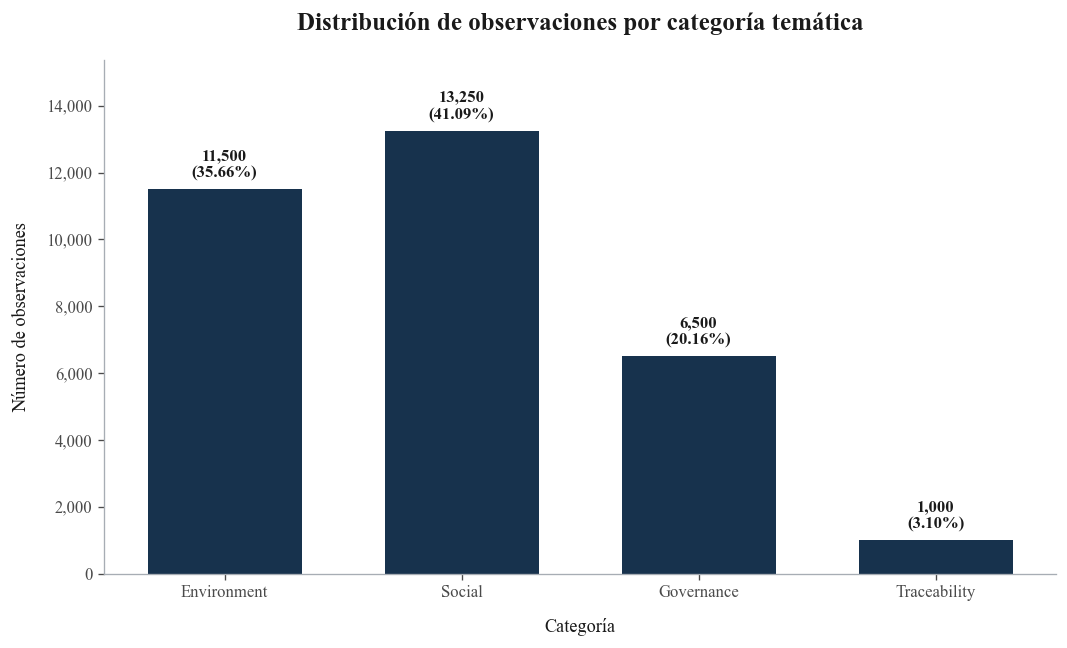

In [143]:
# Visualizamos la distribución de observaciones por categoría temática

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de barras
barras = ax.bar(
    resumen_categorias["Categoria"],
    resumen_categorias["Observaciones"],
    color=AZUL_MARINO,
    width=0.65
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de observaciones por categoría temática",
    pad=18
)

ax.set_xlabel("Categoría", labelpad=10)
ax.set_ylabel("Número de observaciones", labelpad=10)

# Aplicamos separadores de miles al eje vertical
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el número de observaciones y el porcentaje
# correspondiente sobre cada barra
for barra, observaciones, porcentaje in zip(
    barras,
    resumen_categorias["Observaciones"],
    resumen_categorias["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 250,
        f"{observaciones:,.0f}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio superior para las etiquetas
ax.set_ylim(
    0,
    resumen_categorias["Observaciones"].max() * 1.16
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_observaciones_categoria")

plt.show()


La distribución de las observaciones evidencia que la base de datos no se encuentra equilibrada entre categorías temáticas. En conjunto, **Environment** y **Social** concentran el **76.75%** de las observaciones, mientras que **Governance** y **Traceability** representan el **23.25%** restante. Esta composición indica que la información disponible en el *Fashion Transparency Index 2023* se encuentra orientada principalmente hacia indicadores ambientales y sociales, aspecto que debe considerarse al interpretar los resultados obtenidos en las etapas posteriores del análisis exploratorio.

En este sentido, resulta pertinente analizar posteriormente si las diferencias entre categorías responden a distintos marcos regulatorios, niveles de divulgación empresarial o características propias de los indicadores que conforman cada dimensión.

### Distribución de indicadores por categoría temática

Además de analizar la distribución de las observaciones, resulta importante conocer cómo se distribuyen los indicadores entre las distintas categorías temáticas. Este análisis permite identificar el peso de cada dimensión dentro de la estructura del índice, independientemente del número de observaciones registradas por empresa.

In [144]:
# Calculamos el número de indicadores por categoría temática

indicadores_categoria = (
    base[["Metric", "Categoria"]]
    .drop_duplicates()
    .groupby("Categoria")
    .size()
    .reindex(orden, fill_value=0)
    .reset_index(name="Indicadores")
)

# Calculamos el porcentaje de indicadores por categoría
indicadores_categoria["Porcentaje"] = (
    indicadores_categoria["Indicadores"]
    / indicadores_categoria["Indicadores"].sum()
    * 100
).round(2)

# Mostramos el resumen
display(indicadores_categoria)

,Categoria,Indicadores,Porcentaje
0,Environment,46,35.660
1,Social,53,41.090
2,Governance,26,20.160
3,Traceability,4,3.100


Se presenta una representación gráfica de la distribución de los indicadores que conforman el *Fashion Transparency Index 2023*.

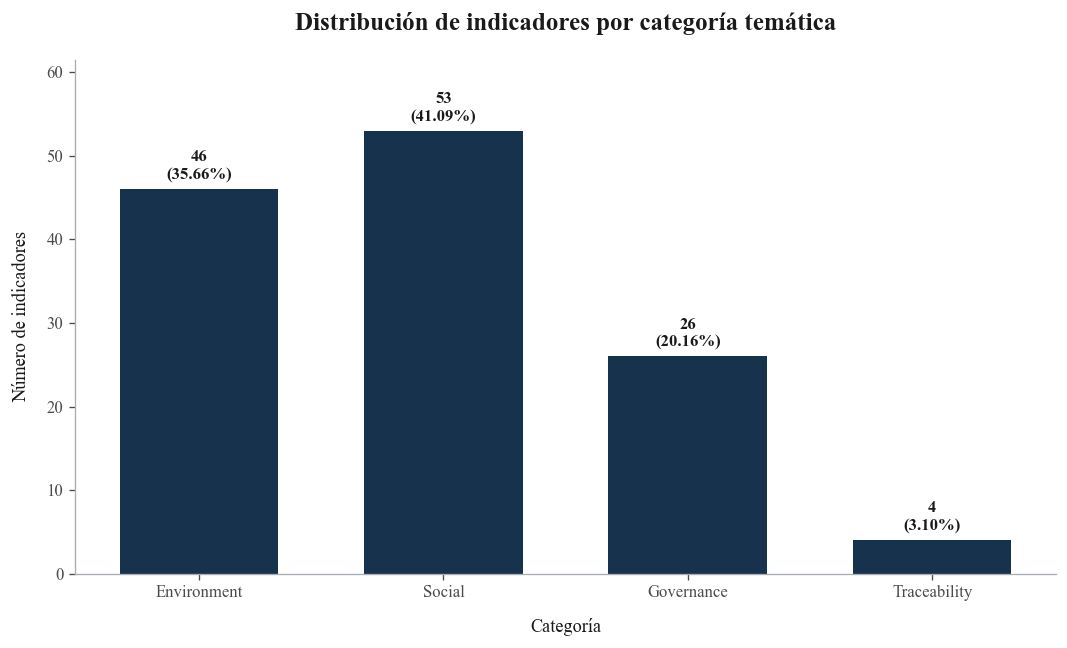

In [145]:
# Visualizamos la distribución de indicadores por categoría temática

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de barras
barras = ax.bar(
    indicadores_categoria["Categoria"],
    indicadores_categoria["Indicadores"],
    color=AZUL_MARINO,
    width=0.65
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de indicadores por categoría temática",
    pad=18
)

ax.set_xlabel("Categoría", labelpad=10)
ax.set_ylabel("Número de indicadores", labelpad=10)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el número de indicadores y el porcentaje correspondiente
for barra, indicadores, porcentaje in zip(
    barras,
    indicadores_categoria["Indicadores"],
    indicadores_categoria["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.8,
        f"{indicadores}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio superior para las etiquetas
ax.set_ylim(
    0,
    indicadores_categoria["Indicadores"].max() * 1.16
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_indicadores_categoria")

plt.show()

La distribución de los indicadores confirma el mismo patrón observado previamente para las observaciones. Esto se debe a que cada indicador fue evaluado para el mismo conjunto de **250 empresas**, por lo que la distribución de las observaciones es directamente proporcional al número de indicadores por categoría. No obstante, este análisis permite identificar la estructura del *Fashion Transparency Index 2023*, evidenciando que **Environment** y **Social** concentran **99 de los 129 indicadores analizados**, mientras que **Governance** y **Traceability** reúnen únicamente **30 indicadores**. Esta diferencia refleja una mayor representación de indicadores ambientales y sociales dentro de la estructura del índice, aspecto que será considerado durante el análisis de los resultados de esta sección.

### Nivel de divulgación de los indicadores

Una vez descrita la composición de la base de datos, se analiza el nivel de divulgación de los indicadores de transparencia.

In [146]:
# Cargamos la matriz binaria utilizada para el análisis

matriz = pd.read_csv("/Users/avrilsalazar/Documents/FashionTransparency2023/processed/matriz_empresas_clustering.csv")

# Calculamos el porcentaje de divulgación por indicador

divulgacion = (
    matriz
    .drop(columns="Company")
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

divulgacion.columns = ["Indicador", "Porcentaje de divulgación"]

In [147]:
# Calculamos estadísticas descriptivas de las tasas de divulgación

estadisticas_divulgacion = (
    divulgacion["Porcentaje de divulgación"]
    .describe()
    .to_frame(name="Valor")
)

# Mostramos el resumen estadístico
display(estadisticas_divulgacion)

,Valor
count,109.000
mean,25.372
std,19.980
min,0.800
25%,7.200
50%,22.400
75%,37.600
max,75.200


A continuación un histograma que muestra la frecuencia de los porcentajes de divulgación observados.

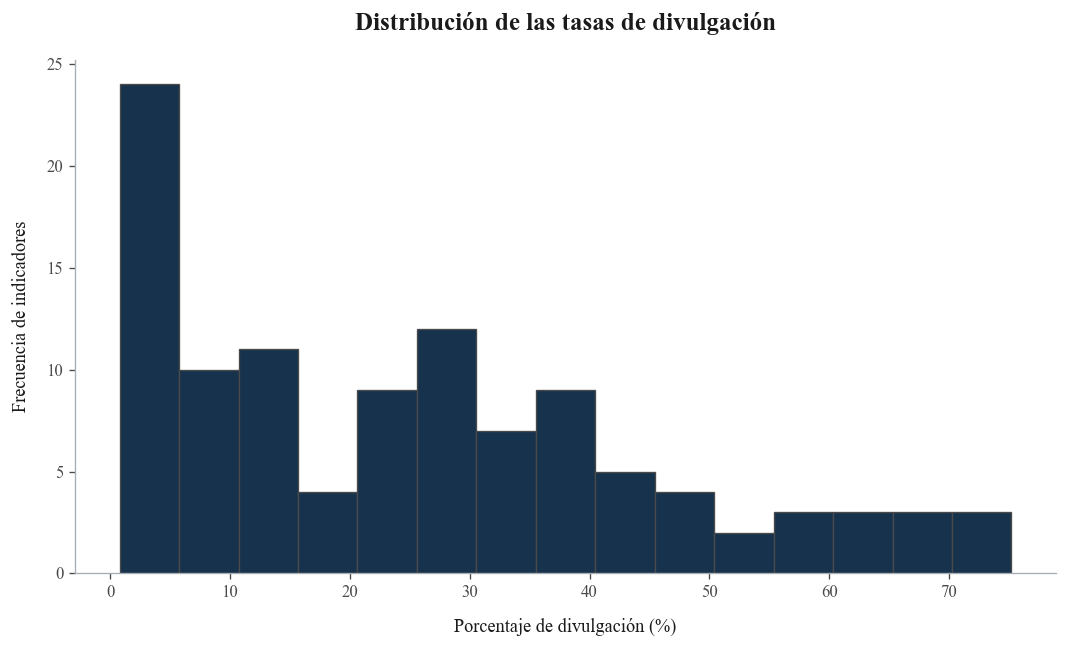

In [148]:
# Visualizamos la distribución de las tasas de divulgación

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos el histograma
ax.hist(
    divulgacion["Porcentaje de divulgación"],
    bins=15,
    color=AZUL_MARINO,
    edgecolor=GRIS_OSCURO,
    linewidth=0.8
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de las tasas de divulgación",
    pad=18
)

ax.set_xlabel("Porcentaje de divulgación (%)", labelpad=10)
ax.set_ylabel("Frecuencia de indicadores", labelpad=10)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_tasas_divulgacion")

plt.show()

Las tasas de divulgación presentan una elevada variabilidad entre indicadores, con valores que oscilan entre **0.8%** y **75.2%**, lo que representa un rango de **74.4 puntos porcentuales**. En promedio, los indicadores son divulgados por el **25.37%** de las empresas. Además, la mediana de **22.40%** indica que la mitad de los indicadores presenta un nivel de divulgación igual o inferior a ese porcentaje. Asimismo, el histograma muestra una mayor concentración de indicadores en los niveles bajos de divulgación y una disminución progresiva de la frecuencia conforme aumenta el porcentaje de empresas que reportan información.

En conjunto, estos resultados evidencian que la transparencia corporativa no se distribuye de manera uniforme entre los indicadores, sino que existe un número reducido de prácticas ampliamente divulgadas y una proporción considerable de indicadores con bajos niveles de reporte.

### Indicadores con mayor nivel de divulgación

Una vez caracterizada la distribución general de las tasas de divulgación, se identifican los indicadores con mayor porcentaje de reporte por parte de las empresas. 

In [149]:
# Identificamos los diez indicadores con mayor nivel de divulgación

top_10_divulgacion = divulgacion.head(10)

# Mostramos el resultado
display(top_10_divulgacion)

,Indicador,Porcentaje de divulgación
0,Fashion Revolution+Supply Chain Policies Align...,75.200
1,Fashion Revolution+Plan for Improving Environm...,71.600
2,Fashion Revolution+Supply Chain Policies Are C...,71.200
3,Fashion Revolution+Describes Human Rights Due ...,67.600
4,Fashion Revolution+Grievance Mechanism - Direc...,67.200
5,Fashion Revolution+Implementation of Board Lev...,66.000
6,Fashion Revolution+New Production Facility Cri...,63.600
7,Fashion Revolution+Reports on Efforts to Impro...,61.200
8,Fashion Revolution+Grievance Mechanism - Suppl...,61.200
9,Fashion Revolution+Discloses Content of Scope ...,59.600


In [150]:
# Reconstruimos la tabla de divulgación con los nombres originales

divulgacion = (
    matriz
    .drop(columns="Company")
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

divulgacion.columns = [
    "Indicador_original",
    "Porcentaje de divulgación"
]

# Recuperamos la categoría temática correspondiente a cada indicador

categorias = (
    base[["Metric", "Categoria"]]
    .drop_duplicates()
    .rename(columns={"Metric": "Indicador_original"})
)

# Incorporamos la categoría temática utilizando los nombres originales

divulgacion = divulgacion.merge(
    categorias,
    on="Indicador_original",
    how="left",
    validate="one_to_one"
)

# Creamos una versión limpia del nombre para tablas y gráficas

divulgacion["Indicador"] = (
    divulgacion["Indicador_original"]
    .str.replace("Fashion Revolution+", "", regex=False)
)

# Reordenamos las columnas

divulgacion = divulgacion[
    [
        "Categoria",
        "Indicador",
        "Porcentaje de divulgación"
    ]
]

# Verificamos que no existan categorías faltantes

print(
    "Categorías faltantes:",
    divulgacion["Categoria"].isna().sum()
)

# Seleccionamos los diez indicadores con mayor divulgación

top_10_divulgacion = divulgacion.head(10).copy()

display(top_10_divulgacion)

Categorías faltantes: 0


,Categoria,Indicador,Porcentaje de divulgación
0,Governance,Supply Chain Policies Align with International...,75.200
1,Environment,Plan for Improving Environmental Impacts,71.600
2,Governance,Supply Chain Policies Are Contractual,71.200
3,Social,Describes Human Rights Due Diligence Process,67.600
4,Social,Grievance Mechanism - Direct Employees,67.200
5,Governance,Implementation of Board Level Accountability D...,66.000
6,Social,New Production Facility Criteria,63.600
7,Environment,Reports on Efforts to Improve Environmental Im...,61.200
8,Social,Grievance Mechanism - Supply Chain Workers,61.200
9,Environment,"Discloses Content of Scope 1, 2 and 3 Emissions",59.600


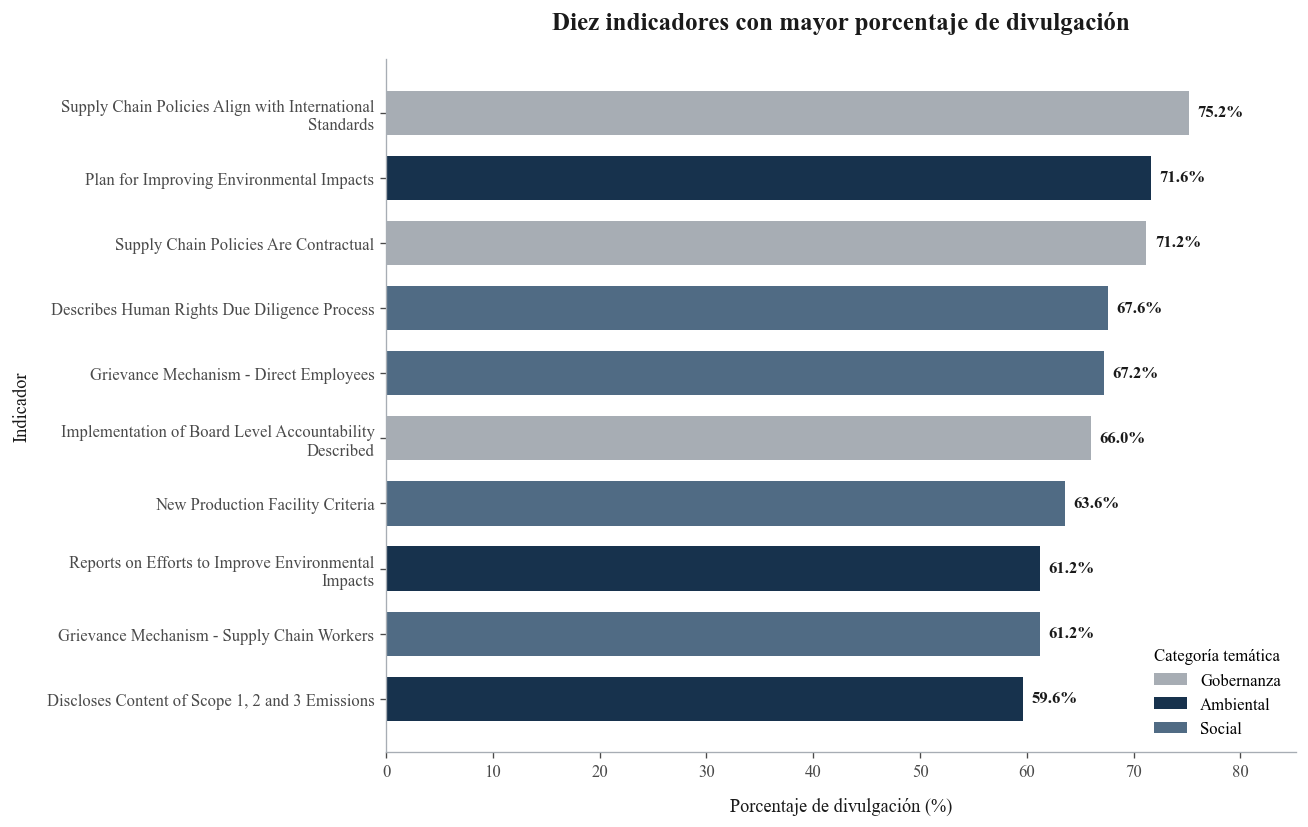

In [151]:
# Visualizamos los diez indicadores con mayor porcentaje de divulgación

import textwrap
from matplotlib.patches import Patch

# Definimos los colores de las categorías temáticas

COLOR_CATEGORIAS = {
    "Environment": AZUL_MARINO,
    "Social": AZUL_SECUNDARIO,
    "Governance": GRIS_MEDIO,
    "Traceability": GRIS_CLARO
}

# Traducimos las categorías únicamente para fines de presentación

CATEGORIAS_ES = {
    "Environment": "Ambiental",
    "Social": "Social",
    "Governance": "Gobernanza",
    "Traceability": "Trazabilidad"
}

# Creamos una copia para preparar las etiquetas de la figura

top_10_grafica = top_10_divulgacion.copy()

# Dividimos automáticamente los nombres largos en varias líneas

top_10_grafica["Indicador_visual"] = (
    top_10_grafica["Indicador"]
    .apply(lambda texto: textwrap.fill(texto, width=48))
)

# Asignamos un color según la categoría temática

colores = (
    top_10_grafica["Categoria"]
    .map(COLOR_CATEGORIAS)
)

# Construimos la figura

fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    top_10_grafica["Indicador_visual"],
    top_10_grafica["Porcentaje de divulgación"],
    color=colores,
    height=0.68
)

# Incorporamos el título y los nombres de los ejes

ax.set_title(
    "Diez indicadores con mayor porcentaje de divulgación",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Mostramos el indicador con mayor divulgación en la parte superior

ax.invert_yaxis()

# Eliminamos los bordes que no aportan información

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje al final de cada barra

for barra, valor in zip(
    barras,
    top_10_grafica["Porcentaje de divulgación"]
):
    ax.text(
        valor + 0.8,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Construimos la leyenda con los nombres de las categorías en español

categorias_presentes = (
    top_10_grafica["Categoria"]
    .drop_duplicates()
)

elementos_leyenda = [
    Patch(
        facecolor=COLOR_CATEGORIAS[categoria],
        label=CATEGORIAS_ES[categoria]
    )
    for categoria in categorias_presentes
]

ax.legend(
    handles=elementos_leyenda,
    title="Categoría temática",
    frameon=False,
    loc="lower right"
)

# Dejamos espacio para mostrar los porcentajes

ax.set_xlim(
    0,
    top_10_grafica["Porcentaje de divulgación"].max() + 10
)

# Ajustamos los márgenes

fig.tight_layout()

# Guardamos la figura en alta resolución

guardar_figura(
    fig,
    "top_10_indicadores_divulgacion"
)

plt.show()

Los indicadores con mayor porcentaje de divulgación presentan niveles de reporte que oscilan entre **59.6%** y **75.2%** de las empresas evaluadas. El indicador con mayor divulgación corresponde a **Supply Chain Policies Align with International Standards** (*informa si las políticas para la cadena de suministro están alineadas con estándares internacionales*), reportado por el **75.2%** de las empresas, mientras que el décimo lugar (**Discloses Content of Scope 1, 2 and 3 Emissions** (*divulga el contenido de las emisiones de alcance 1, 2 y 3*)) alcanza un **59.6%**. La diferencia entre ambos es de **15.6 puntos porcentuales**, lo que indica que incluso entre las prácticas más ampliamente divulgadas existe variabilidad en el grado de adopción.

Asimismo, se observa que los diez indicadores pertenecen exclusivamente a las categorías **Gobernanza**, **Ambiental** y **Social**. En particular, **cuatro** corresponden a la dimensión Social, **tres** a Gobernanza y **tres** a Ambiental, mientras que **ningún** indicador de Trazabilidad aparece entre los niveles más altos de divulgación. En conjunto, estos resultados muestran que los indicadores con mayor nivel de divulgación se concentran principalmente en políticas corporativas, mecanismos de gobernanza, procesos de debida diligencia y acciones relacionadas con la gestión de impactos ambientales y sociales.

### Indicadores con menor nivel de divulgación

A continuación, se identifican los diez indicadores con menor porcentaje de divulgación dentro del Fashion Transparency Index 2023. Este análisis permite reconocer las prácticas sobre las cuales las empresas proporcionan información con menor frecuencia.

In [152]:
# Identificamos los diez indicadores con menor nivel de divulgación

bottom_10_divulgacion = divulgacion.tail(10).copy()

# Mostramos el resultado

display(bottom_10_divulgacion)

,Categoria,Indicador,Porcentaje de divulgación
99,Governance,Discloses Free on Board (FOB) Price Changes (C...,2.000
100,Social,Discloses Strategy to Achieving Living Wage,2.000
101,Social,Reports on Minimum Wage Paid for Daily / Piece...,1.600
102,Environment,Discloses Percentage of Workers Paid By Piece ...,1.600
103,Social,Discloses Progress toward the payment of a Liv...,1.600
104,Social,Discloses Number of Collective Bargaining Agre...,1.200
105,Social,Publishes Percentage or Number of Workers Earn...,1.200
106,Governance,Discloses Policy on Up-Front Supplier Payments,0.800
107,Environment,Commitment to Degrowth,0.800
108,Governance,Publishes Standard Supplier Agreement Template,0.800


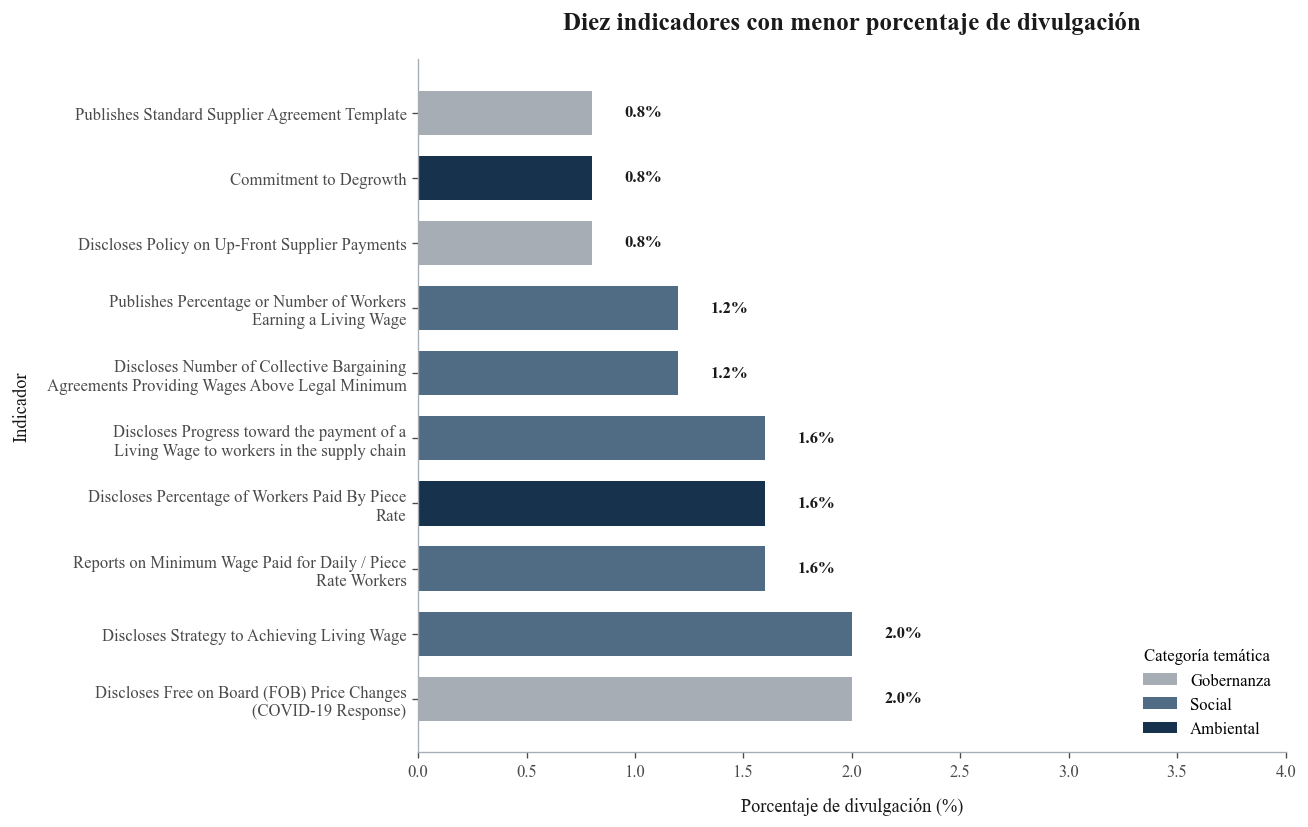

In [153]:
# Visualizamos los diez indicadores con menor porcentaje de divulgación

import textwrap
from matplotlib.patches import Patch

# Creamos una copia para preparar las etiquetas de la figura

bottom_10_grafica = bottom_10_divulgacion.copy()

# Dividimos automáticamente los nombres largos en varias líneas

bottom_10_grafica["Indicador_visual"] = (
    bottom_10_grafica["Indicador"]
    .apply(lambda texto: textwrap.fill(texto, width=48))
)

# Asignamos un color según la categoría temática

colores = (
    bottom_10_grafica["Categoria"]
    .map(COLOR_CATEGORIAS)
)

# Construimos la figura

fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    bottom_10_grafica["Indicador_visual"],
    bottom_10_grafica["Porcentaje de divulgación"],
    color=colores,
    height=0.68
)

# Incorporamos el título y los nombres de los ejes

ax.set_title(
    "Diez indicadores con menor porcentaje de divulgación",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Eliminamos los bordes que no aportan información

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje al final de cada barra

for barra, valor in zip(
    barras,
    bottom_10_grafica["Porcentaje de divulgación"]
):
    ax.text(
        valor + 0.15,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Construimos la leyenda

categorias_presentes = (
    bottom_10_grafica["Categoria"]
    .drop_duplicates()
)

elementos_leyenda = [
    Patch(
        facecolor=COLOR_CATEGORIAS[categoria],
        label=CATEGORIAS_ES[categoria]
    )
    for categoria in categorias_presentes
]

ax.legend(
    handles=elementos_leyenda,
    title="Categoría temática",
    frameon=False,
    loc="lower right"
)

# Dejamos espacio para mostrar los porcentajes

ax.set_xlim(0, 4)

# Ajustamos los márgenes

fig.tight_layout()

# Guardamos la figura

guardar_figura(
    fig,
    "bottom_10_indicadores_divulgacion"
)

plt.show()

Los indicadores con menor porcentaje de divulgación presentan niveles de reporte que oscilan entre **0.8%** y **2.0%** de las empresas evaluadas. El indicador con mayor divulgación dentro de este grupo corresponde a **Discloses Free on Board (FOB) Price Changes (COVID-19 Response)** (*divulga cambios en los precios Free on Board (FOB) como respuesta a la COVID-19*) y **Discloses Strategy to Achieving Living Wage** (*divulga la estrategia para lograr el pago de un salario digno*), ambos reportados por únicamente el **2.0%** de las empresas. En contraste, los indicadores **Discloses Policy on Up-Front Supplier Payments** (*divulga una política de pagos anticipados a proveedores*), **Commitment to Degrowth** (*compromiso con estrategias de decrecimiento para reducir el impacto ambiental*) y **Publishes Standard Supplier Agreement Template** (*publica un modelo estándar de contrato para proveedores*) son reportados por apenas el **0.8%** de las empresas. La diferencia entre el indicador con mayor y menor divulgación dentro de este grupo es de **1.2 puntos porcentuales**, lo que evidencia que todos estos indicadores presentan niveles de divulgación extremadamente bajos.

Asimismo, se observa que **cinco** de los diez indicadores pertenecen a la categoría **Social**, **tres** a **Gobernanza** y **dos** a **Ambiental**, mientras que nuevamente no aparece ningún indicador de **Trazabilidad**. Destaca que la mayoría de estos indicadores está relacionada con **salarios dignos, negociación colectiva, condiciones de pago a proveedores y prácticas laborales**, temas que requieren un mayor nivel de transparencia sobre la relación de las empresas con sus trabajadores y su cadena de suministro. En conjunto, estos resultados sugieren que, aunque algunas empresas divulgan ampliamente sus políticas generales de sostenibilidad y gobernanza, existe una marcada resistencia a reportar información específica sobre condiciones laborales, remuneración y mecanismos contractuales, lo que constituye una de las principales brechas de transparencia observadas en el *Fashion Transparency Index 2023*.

### Nivel promedio de divulgación por categoría temática

A continuación, se calcula el porcentaje promedio de divulgación de los indicadores pertenecientes a cada categoría temática, esto permite comparar el nivel general de transparencia entre las dimensiones Ambiental, Social, Gobernanza y Trazabilidad.

In [154]:
# Calculamos el porcentaje promedio de divulgación por categoría temática

divulgacion_categoria = (
    divulgacion
    .groupby("Categoria", as_index=False)
    ["Porcentaje de divulgación"]
    .mean()
    .round(2)
    .sort_values(
        by="Porcentaje de divulgación",
        ascending=False
    )
    .reset_index(drop=True)
)

# Incorporamos los nombres de las categorías en español para su presentación

divulgacion_categoria["Categoria_es"] = (
    divulgacion_categoria["Categoria"]
    .map(CATEGORIAS_ES)
)

# Reordenamos las columnas

divulgacion_categoria = divulgacion_categoria[
    [
        "Categoria",
        "Categoria_es",
        "Porcentaje de divulgación"
    ]
]

# Mostramos el resultado

display(divulgacion_categoria)

,Categoria,Categoria_es,Porcentaje de divulgación
0,Governance,Gobernanza,30.420
1,Environment,Ambiental,25.940
2,Social,Social,22.780


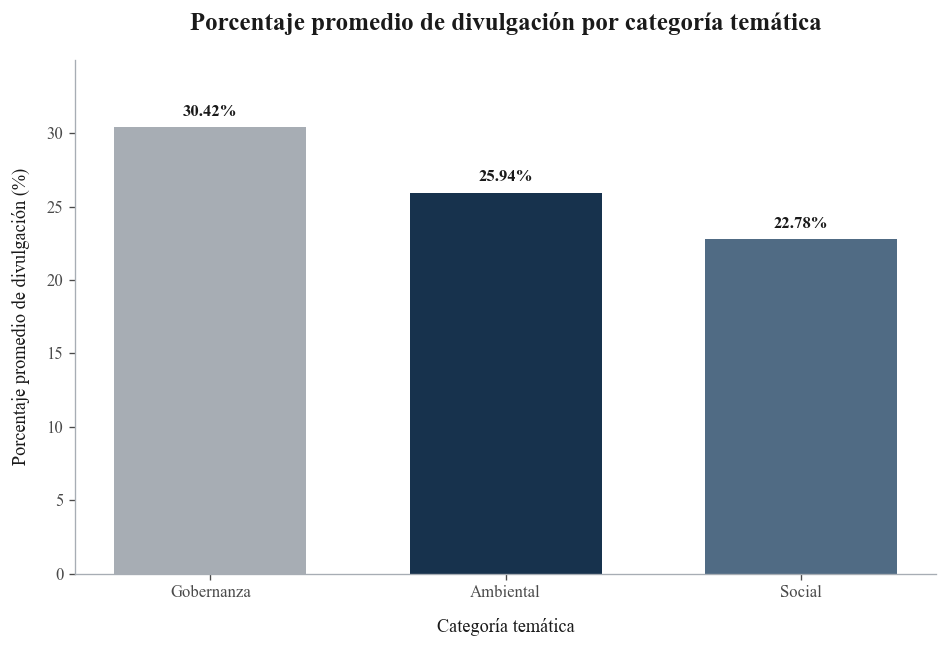

In [155]:
# Visualizamos el porcentaje promedio de divulgación por categoría temática

fig, ax = plt.subplots(figsize=(8, 5.5))

# Asignamos un color según la categoría temática

colores = (
    divulgacion_categoria["Categoria"]
    .map(COLOR_CATEGORIAS)
)

# Construimos la gráfica

barras = ax.bar(
    divulgacion_categoria["Categoria_es"],
    divulgacion_categoria["Porcentaje de divulgación"],
    color=colores,
    width=0.65
)

# Incorporamos el título y los nombres de los ejes

ax.set_title(
    "Porcentaje promedio de divulgación por categoría temática",
    pad=18
)

ax.set_xlabel(
    "Categoría temática",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Eliminamos los bordes que no aportan información

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra

for barra, valor in zip(
    barras,
    divulgacion_categoria["Porcentaje de divulgación"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio para las etiquetas

ax.set_ylim(
    0,
    divulgacion_categoria["Porcentaje de divulgación"].max() * 1.15
)

# Ajustamos los márgenes

fig.tight_layout()

# Guardamos la figura

guardar_figura(
    fig,
    "promedio_divulgacion_categoria"
)

plt.show()

El nivel promedio de divulgación varía entre las distintas categorías temáticas del índice. La categoría **Gobernanza** presenta el mayor porcentaje promedio de divulgación (**30.42%**), seguida de **Ambiental** (**25.94%**) y **Social** (**22.78%**). En consecuencia, los indicadores de Gobernanza son divulgados, en promedio, **7.64 puntos porcentuales** más que los indicadores Sociales y **4.48 puntos porcentuales** más que los Ambientales.

Estos resultados son consistentes con los análisis anteriores. Mientras que entre los indicadores con mayor nivel de divulgación predominan políticas corporativas, mecanismos de gobernanza y procesos generales de gestión, los indicadores con menor divulgación se concentran principalmente en temas relacionados con **salarios dignos, negociación colectiva y condiciones laborales**, pertenecientes en su mayoría a la dimensión Social. En conjunto, la evidencia sugiere que las empresas muestran una mayor disposición a divulgar información sobre estructuras de gobernanza y compromisos institucionales que sobre aspectos específicos de las condiciones laborales dentro de su cadena de suministro.